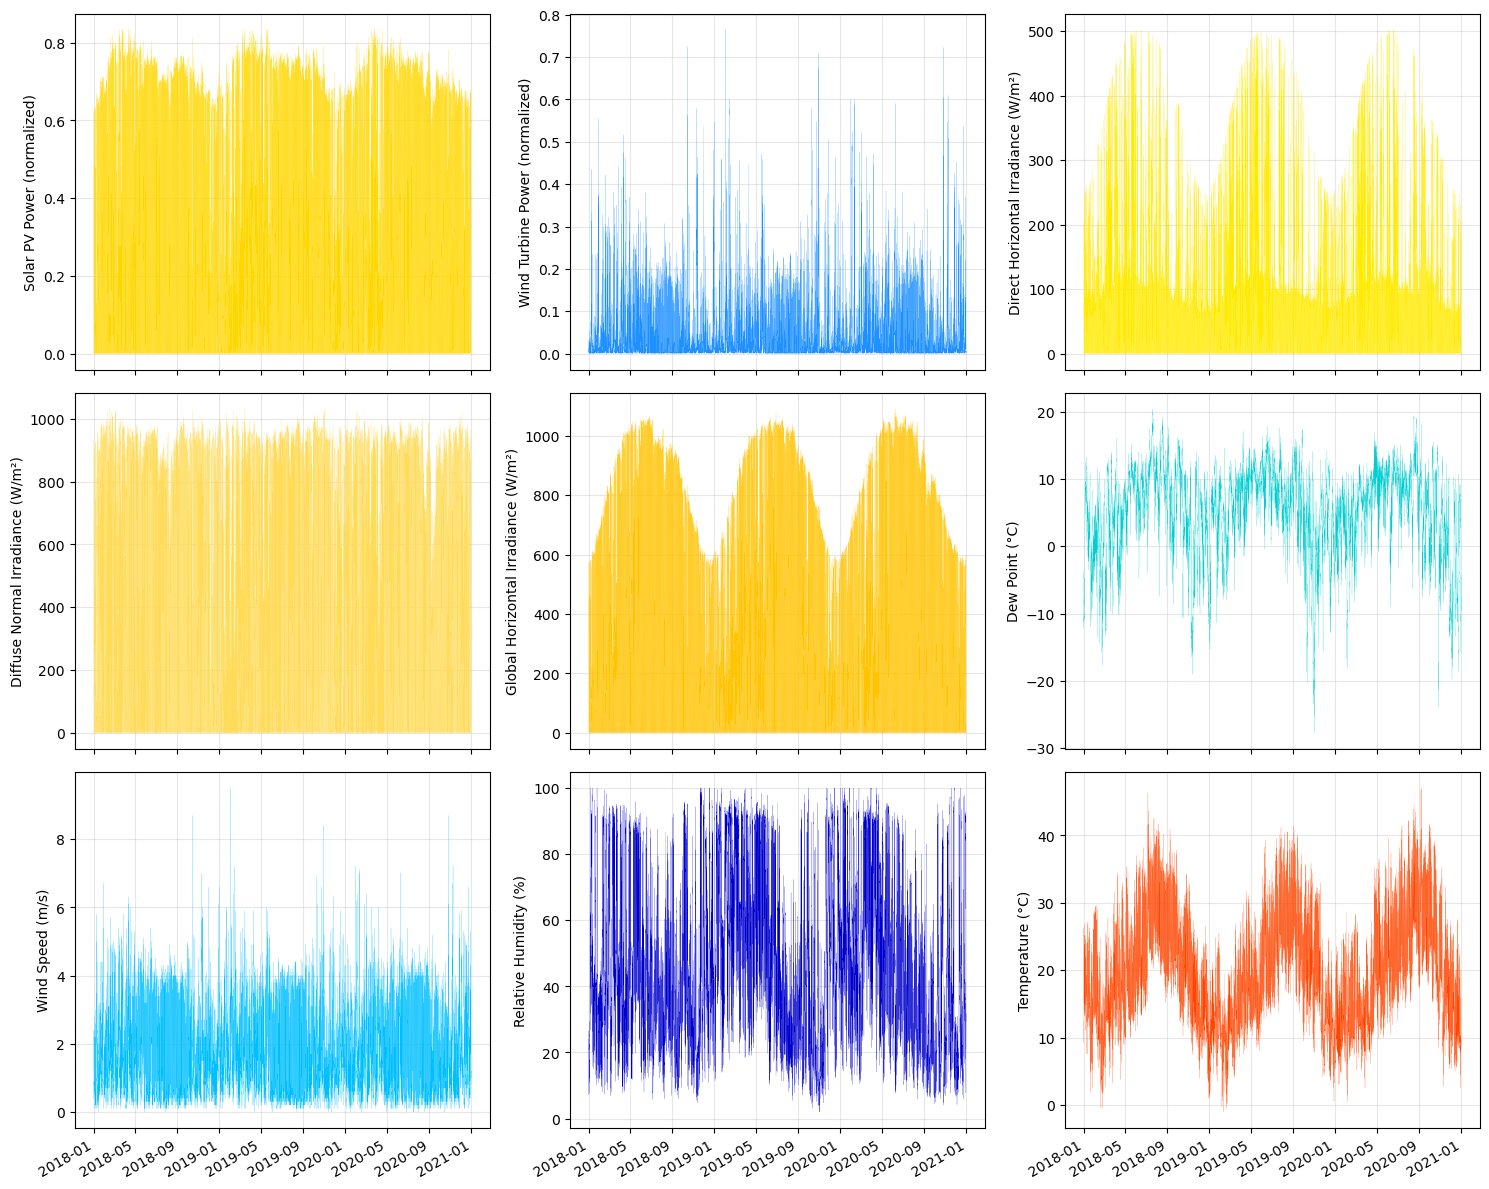

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# ─── PARAMETERS ────────────────────────────────────────────────────────────────

csv_path   = "Dataset/PSML.csv"               # ← path to your CSV
start_date = "2018-01-01"                  # ← adjust as needed
end_date   = "2020-12-31"                  # ← adjust as needed

# ─── METADATA DICTIONARIES ─────────────────────────────────────────────────────

# Units for each variable
units = {
    "solar_power":       "normalized",
    "wind_power":        "normalized",
    "DHI":               "W/m²",
    "DNI":               "W/m²",
    "GHI":               "W/m²",
    "Dew Point":         "°C",
    "Wind Speed":        "m/s",
    "Relative Humidity": "%",
    "Temperature":       "°C"
}

# Custom y‐axis labels (no units here; units added automatically)
label_map = {
    "solar_power":       "Solar PV Power",
    "wind_power":        "Wind Turbine Power",
    "DHI":               "Direct Horizontal Irradiance",
    "DNI":               "Diffuse Normal Irradiance",
    "GHI":               "Global Horizontal Irradiance",
    "Dew Point":         "Dew Point",
    "Wind Speed":        "Wind Speed",
    "Relative Humidity": "Relative Humidity",
    "Temperature":       "Temperature"
}

# Plotting colors per series
color_map = {
    "solar_power":       "#FFD700",  # Gold
    "wind_power":        "#1E90FF",  # DodgerBlue
    "DHI":               "#FFEA00",  # Sun‐beam Yellow
    "DNI":               "#FFDB58",  # Mustard Yellow
    "GHI":               "#FFC300",  # Amber
    "Dew Point":         "#00CED1",  # DarkTurquoise (moisture)
    "Wind Speed":        "#00BFFF",  # DeepSkyBlue
    "Relative Humidity": "#0000CD",  # MediumBlue
    "Temperature":       "#FF4500"   # OrangeRed (warmth)
}

# ─── LOAD & PREPARE DATA ───────────────────────────────────────────────────────

# 1) Load and index by time
df = pd.read_csv(csv_path, parse_dates=["time"])
df.set_index("time", inplace=True)

# 2) Subset to desired date range
df = df.loc[start_date : end_date]

# 3) Drop the second column and 'Solar Zenith Angle' if present
to_drop = [df.columns[0], "Solar Zenith Angle"]
df = df.drop(columns=to_drop, errors="ignore")

# 4) Define the exact 3×3 plotting order
plot_cols = [
    "solar_power",
    "wind_power",
    "DHI",
    "DNI",
    "GHI",
    "Dew Point",
    "Wind Speed",
    "Relative Humidity",
    "Temperature"
]

# ─── PLOTTING ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    color = color_map.get(col, "black")
    yseries = df[col]
    
    ax.plot(df.index, yseries, color=color, linewidth=0.1)
    
    # Y‐axis label = custom label + units
    lab = label_map.get(col, col.replace("_"," ").title())
    unit = units.get(col, "")
    ax.set_ylabel(f"{lab} ({unit})", fontsize=10)
    
    ax.grid(alpha=0.3)

# Rotate x‐labels only on bottom row (axes 6,7,8)
for ax in axes[6:]:
    plt.sca(ax)
    plt.xticks(rotation=30, ha="right")

# Remove any extra axes if necessary
for ax in axes[len(plot_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.savefig(f"psml_viz.png", dpi=300, bbox_inches='tight')
plt.show()